In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
sigara_verisi = pd.read_csv('sigara_olumOranı_dataset.csv')
sigara_verisi

,Yıl,Sigara İçen Kişi Sayısı (milyon),Sigaradan Ölen Kişi Sayısı (milyon),Toplam Ölen Kişi Sayısı (milyon)
0,2000,1.638,4.9,54.8
1,2001,1.643,5.0,55.3
2,2002,1.648,5.1,56.0
3,2003,1.653,5.2,56.6
4,2004,1.658,5.3,57.2
5,2005,1.672,5.4,58.8
6,2006,1.677,5.5,59.4
7,2007,1.682,5.6,60.0
8,2008,1.687,5.7,60.6
9,2009,1.692,5.8,61.2


In [3]:
sigara_verisi.columns

Index(['Yıl', 'Sigara İçen Kişi Sayısı (milyon)',
       'Sigaradan Ölen Kişi Sayısı (milyon)',
       'Toplam Ölen Kişi Sayısı (milyon)'],
      dtype='object')

In [4]:
sigara_verisi["Sigara İçenlerin Ölüm Oranı"] = ((sigara_verisi["Sigaradan Ölen Kişi Sayısı (milyon)"] / sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"])*100).apply(lambda x: f"% {x:.2f}")
sigara_verisi.head()

,Yıl,Sigara İçen Kişi Sayısı (milyon),Sigaradan Ölen Kişi Sayısı (milyon),Toplam Ölen Kişi Sayısı (milyon),Sigara İçenlerin Ölüm Oranı
0,2000,1.638,4.9,54.8,% 8.94
1,2001,1.643,5.0,55.3,% 9.04
2,2002,1.648,5.1,56.0,% 9.11
3,2003,1.653,5.2,56.6,% 9.19
4,2004,1.658,5.3,57.2,% 9.27


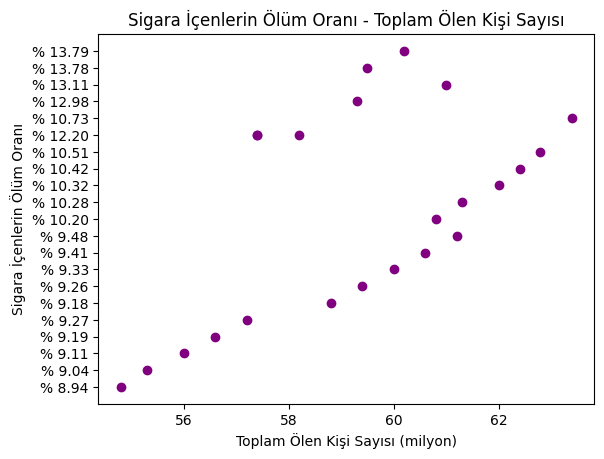

In [5]:
plt.scatter(sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"], sigara_verisi["Sigara İçenlerin Ölüm Oranı"], color="purple")
plt.xlabel('Toplam Ölen Kişi Sayısı (milyon)')
plt.ylabel('Sigara İçenlerin Ölüm Oranı')
plt.title('Sigara İçenlerin Ölüm Oranı - Toplam Ölen Kişi Sayısı')
plt.show()

In [6]:
sigara_verisi['Sigara İçenlerin Ölüm Oranı'] = sigara_verisi['Sigara İçenlerin Ölüm Oranı'].replace({'%': '', ' ': ''}, regex=True).astype(float)

In [7]:
kmeans = KMeans(n_clusters=6)
kmeans.fit(sigara_verisi[['Toplam Ölen Kişi Sayısı (milyon)', 'Sigara İçenlerin Ölüm Oranı']])
sigara_verisi['Küme'] = kmeans.predict(sigara_verisi[['Toplam Ölen Kişi Sayısı (milyon)', 'Sigara İçenlerin Ölüm Oranı']])
sigara_verisi

,Yıl,Sigara İçen Kişi Sayısı (milyon),Sigaradan Ölen Kişi Sayısı (milyon),Toplam Ölen Kişi Sayısı (milyon),Sigara İçenlerin Ölüm Oranı,Küme
0,2000,1.638,4.9,54.8,8.94,2
1,2001,1.643,5.0,55.3,9.04,2
2,2002,1.648,5.1,56.0,9.11,2
3,2003,1.653,5.2,56.6,9.19,2
4,2004,1.658,5.3,57.2,9.27,2
5,2005,1.672,5.4,58.8,9.18,0
6,2006,1.677,5.5,59.4,9.26,0
7,2007,1.682,5.6,60.0,9.33,0
8,2008,1.687,5.7,60.6,9.41,0
9,2009,1.692,5.8,61.2,9.48,3


In [8]:
kmeans.cluster_centers_

array([[59.7       ,  9.295     ],
       [60.6       , 13.45      ],
       [55.98      ,  9.11      ],
       [61.98571429, 10.27714286],
       [59.4       , 13.38      ],
       [57.66666667, 12.2       ]])

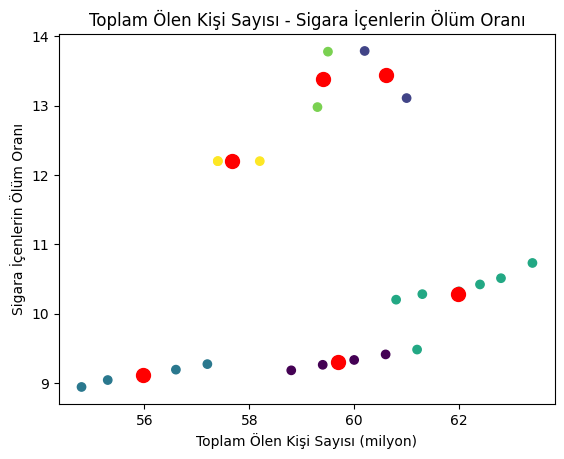

In [9]:
plt.scatter(sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"], sigara_verisi["Sigara İçenlerin Ölüm Oranı"], c = sigara_verisi["Küme"])
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red')
plt.xlabel('Toplam Ölen Kişi Sayısı (milyon)')
plt.ylabel('Sigara İçenlerin Ölüm Oranı')
plt.title('Toplam Ölen Kişi Sayısı - Sigara İçenlerin Ölüm Oranı')
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(sigara_verisi[['Toplam Ölen Kişi Sayısı (milyon)', 'Sigara İçenlerin Ölüm Oranı']])
sigara_verisi['Küme'] = kmeans.labels_
sigara_verisi
           

,Yıl,Sigara İçen Kişi Sayısı (milyon),Sigaradan Ölen Kişi Sayısı (milyon),Toplam Ölen Kişi Sayısı (milyon),Sigara İçenlerin Ölüm Oranı,Küme
0,2000,1.638,4.9,54.8,8.94,2
1,2001,1.643,5.0,55.3,9.04,2
2,2002,1.648,5.1,56.0,9.11,2
3,2003,1.653,5.2,56.6,9.19,2
4,2004,1.658,5.3,57.2,9.27,2
5,2005,1.672,5.4,58.8,9.18,0
6,2006,1.677,5.5,59.4,9.26,0
7,2007,1.682,5.6,60.0,9.33,0
8,2008,1.687,5.7,60.6,9.41,0
9,2009,1.692,5.8,61.2,9.48,1


In [11]:
kmeans.cluster_centers_

array([[59.7       ,  9.295     ],
       [61.98571429, 10.27714286],
       [55.98      ,  9.11      ],
       [59.        , 12.89428571]])

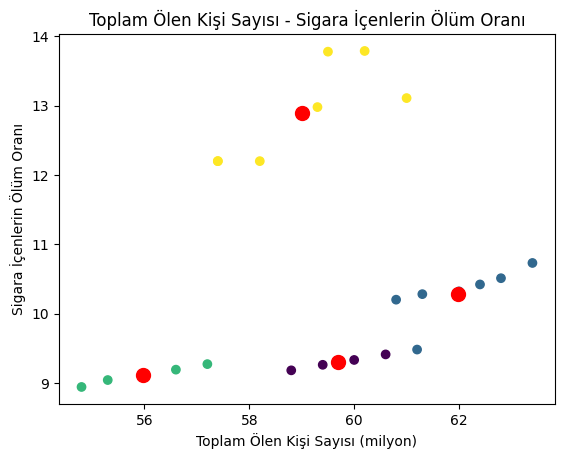

In [12]:
plt.scatter(sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"], sigara_verisi["Sigara İçenlerin Ölüm Oranı"], c = sigara_verisi["Küme"])
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red')
plt.xlabel('Toplam Ölen Kişi Sayısı (milyon)')
plt.ylabel('Sigara İçenlerin Ölüm Oranı')
plt.title('Toplam Ölen Kişi Sayısı - Sigara İçenlerin Ölüm Oranı')
plt.show()